# Analize data cvs files
## Author: Ilyas
## Date: 9 oktober

## Import dependences and read data

In [29]:
import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
path_area = r"F:\projects\Forest-Hackathon\data\raw\5. Объединение фрагментированных выделов\Таксационные описания 20260928 (выдел)_зпт.csv"
path_teenager = r"F:\projects\Forest-Hackathon\data\raw\5. Объединение фрагментированных выделов\Таксационные описания 20260928 (подрост)_зпт.csv"
path_tier = r"F:\projects\Forest-Hackathon\data\raw\5. Объединение фрагментированных выделов\Таксационные описания 20260928 (ярус)_зпт.csv"

path_geo_forestsec1 = r"F:\projects\Forest-Hackathon\data\raw\5. Объединение фрагментированных выделов\Лесосеки-1.geojson"
path_geo_forestsec2 = r"F:\projects\Forest-Hackathon\data\raw\5. Объединение фрагментированных выделов\Лесосеки-2.geojson"
path_geo_area = r"F:\projects\Forest-Hackathon\data\raw\5. Объединение фрагментированных выделов\Выделы под лесосеками.geojson"

cvs files open with cp1251 encoding and separator ;

In [25]:
df_area = pd.read_csv(path_area, encoding='cp1251', sep=';')
df_teenager = pd.read_csv(path_teenager, encoding='cp1251', sep=';')
df_tier = pd.read_csv(path_tier, encoding='cp1251', sep=';')

df_geo_forestsec1 = gpd.read_file(path_geo_forestsec1)
df_geo_forestsec2 = gpd.read_file(path_geo_forestsec2)
df_geo_area = gpd.read_file(path_geo_area)

C:\Temp\ipykernel_4464\2915679404.py:3: DtypeWarning: Columns (3: Лесоустроительный номер выдела, 4: Номер лесного яруса) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tier = pd.read_csv(path_tier, encoding='cp1251', sep=';')


* df_area - main data about areas and main information about their forest
* df_tier - groups of forest. One area can have many tiers (1 - 3)
* df_teenager - groups of new forest, like a tier

In [ ]:
Count data

In [26]:
print(f"Area data count: {df_area.size}")
print(f"Teenager data count: {df_teenager.size}")
print(f"Tier data count: {df_tier.size}")
print()
print(f"Geo ForestSec1 data count: {df_geo_forestsec1.size}")
print(f"Geo ForestSec2 data count: {df_geo_forestsec2.size}")
print(f"Geo area data count: {df_geo_area.size}")

Area data count: 1105965
Teenager data count: 451570
Tier data count: 3471984

Geo ForestSec1 data count: 576
Geo ForestSec2 data count: 18904
Geo area data count: 526268


## Drop unnecessary columns

In [5]:
df_area.drop("Код региона", axis=1, inplace=True)
df_teenager.drop("Код региона", axis=1, inplace=True)
df_tier.drop("Код региона", axis=1, inplace=True)

## See information of all tables

In [6]:
df_area.sample(2)

,Регистрационный номер квартала,Регистрационный номер выдела,Лесоустроительный номер выдела,Дата лесоустройства,Площадь выдела,Общий запас лесных насаждений,Наименование типа земель,Наименование вида лесных земель,Наименование вида нелесных земель,Наименование типа леса,Наименование типа лесорастительных условий,Общий запас сухостоя,Общий запас естественных редин,Общий запас единичных деревьев,Общий запас неликвидной древесины,Год посадки (начала формирования),Хозяйственная категория,Код преобладающей породы,Преобладающая порода,Класс бонитета
32957,22:14:6:96,22:14:6:96:18,16,01.01.2023,"0,9",23,Лесные земли,Насаждение естественного происхождения,NaN,свежий бор,NaN,NaN,NaN,NaN,NaN,1915.0,Хвойное,100100.0,Сосна,2
9657,38:21:1:196,38:21:1:196:17,17,01.01.1917,"16,6",232,Лесные земли,Насаждение естественного происхождения,NaN,NaN,C2,10.0,NaN,NaN,NaN,1980.0,NaN,302600.0,Береза,2


In [7]:
df_teenager.sample(2)

,Регистрационный номер квартала,Регистрационный номер выдела,Лесоустроительный номер выдела,Средняя высота подроста в метрах,Средний возраст лет,Количество подроста на гектар,Состав подроста (формула состава),Код оценки подроста,Оценка подроста,Код породы подроста,Наименование породы подроста,Доля участия породы подроста,Преобладающая древесная порода подроста
26637,38:26:4:106,38:26:4:106:1,6,2.5,30.0,4.0,4Е4П2К,NaN,NaN,100300,Пихта,4.0,N
18918,29:28:4:69,29:28:4:69:33,31,1.0,40.0,1.0,10Е,NaN,NaN,100200,Ель,10.0,N


In [8]:
df_tier.sample(2)

,Регистрационный номер квартала,Регистрационный номер выдела,Лесоустроительный номер выдела,Номер лесного яруса,Является ли ярус основным,Средняя высота яруса лесного насаждения в метрах,Средняя высота яруса лесного насаждения в метрах.1,Состав лесного насаждения,Средний возраст,Средний диаметр ствола,...,Наименование древесной породы либо кустарниковой породы,Является ли преобладающей древесной породой,Доля участия древесной породы в составе яруса лесного насаждения в долях единицы,Возраст древесной породы (лет),Высота древесной породы в метрах с округлением до 1 метра,Средний диаметр ствола в сантиметрах с округлением до 1 сантиметра,Наименование класса возраста,Код группы возраста лесного насаждения,Наименование группы возраста лесного насаждения,Запас древесины составляющих древесных пород на 1 гектар
93306,22:14:1:102,22:14:1:102:37,40,1,Y,25.666667,NaN,7С2С1С,NaN,NaN,...,Сосна,N,1.0,150.0,27.0,44.0,6.0,NaN,NaN,NaN
140177,53:15:6:138,53:15:6:138:26,24,1,Y,23.666667,NaN,6ОС2Б2ОЛЧ,NaN,NaN,...,Осина,Y,6.0,75.0,24.0,26.0,8.0,40060008.0,перестойные,323.0


In [13]:
df_area.merge(df_teenager, on='Регистрационный номер выдела', how='inner').merge(df_tier, on='Регистрационный номер выдела', how='inner')

,Регистрационный номер квартала_x,Регистрационный номер выдела,Лесоустроительный номер выдела_x,Дата лесоустройства,Площадь выдела,Общий запас лесных насаждений,Наименование типа земель,Наименование вида лесных земель,Наименование вида нелесных земель,Наименование типа леса,...,Наименование древесной породы либо кустарниковой породы,Является ли преобладающей древесной породой,Доля участия древесной породы в составе яруса лесного насаждения в долях единицы,Возраст древесной породы (лет),Высота древесной породы в метрах с округлением до 1 метра,Средний диаметр ствола в сантиметрах с округлением до 1 сантиметра,Наименование класса возраста,Код группы возраста лесного насаждения,Наименование группы возраста лесного насаждения,Запас древесины составляющих древесных пород на 1 гектар
0,44:8:3:83,44:8:3:83:27,4,NaN,"2,2",700,Лесные земли,Насаждение естественного происхождения,NaN,Сосняк черничный,...,Сосна,Y,5.0,85.0,25.0,28.0,5.0,40050007.0,спелые,320.0
1,44:8:3:83,44:8:3:83:27,4,NaN,"2,2",700,Лесные земли,Насаждение естественного происхождения,NaN,Сосняк черничный,...,Береза,N,5.0,NaN,25.0,26.0,5.0,NaN,NaN,NaN
2,44:8:3:83,44:8:3:83:38,15,NaN,"36,8",9200,Лесные земли,Насаждение естественного происхождения,NaN,Сосняк черничный,...,Береза,Y,5.0,80.0,25.0,26.0,8.0,40050007.0,спелые,250.0
3,44:8:3:83,44:8:3:83:38,15,NaN,"36,8",9200,Лесные земли,Насаждение естественного происхождения,NaN,Сосняк черничный,...,Осина,N,3.0,NaN,26.0,32.0,8.0,NaN,NaN,NaN
4,44:8:3:83,44:8:3:83:38,15,NaN,"36,8",9200,Лесные земли,Насаждение естественного происхождения,NaN,Сосняк черничный,...,Ель,N,2.0,NaN,25.0,30.0,8.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122142,37:10:1:36,37:10:1:36:17,21,NaN,"13,3",29260,Лесные земли,Насаждение естественного происхождения,NaN,Сосняк сложный(липово-дубняковый),...,Береза,Y,6.0,55.0,26.0,22.0,6.0,40030005.0,приспевающие,2200.0
122143,37:10:1:36,37:10:1:36:6,7,NaN,"13,6",24480,Лесные земли,Насаждение естественного происхождения,NaN,Сосняк сложный(липово-дубняковый),...,Береза,Y,6.0,90.0,28.0,32.0,9.0,40050007.0,спелые,1800.0
122144,37:10:1:36,37:10:1:36:22,27,NaN,"5,5",13200,Лесные земли,Насаждение естественного происхождения,NaN,Ельник сложный (липняковый-дубняковый),...,Береза,Y,7.0,65.0,27.0,24.0,7.0,40050007.0,спелые,2400.0
122145,37:10:1:36,37:10:1:36:19,28,NaN,"7,6",17480,Лесные земли,Насаждение естественного происхождения,NaN,Сосняк сложный(липово-дубняковый),...,Береза,Y,5.0,55.0,26.0,22.0,6.0,40030005.0,приспевающие,2300.0


## Visulization in map geojson

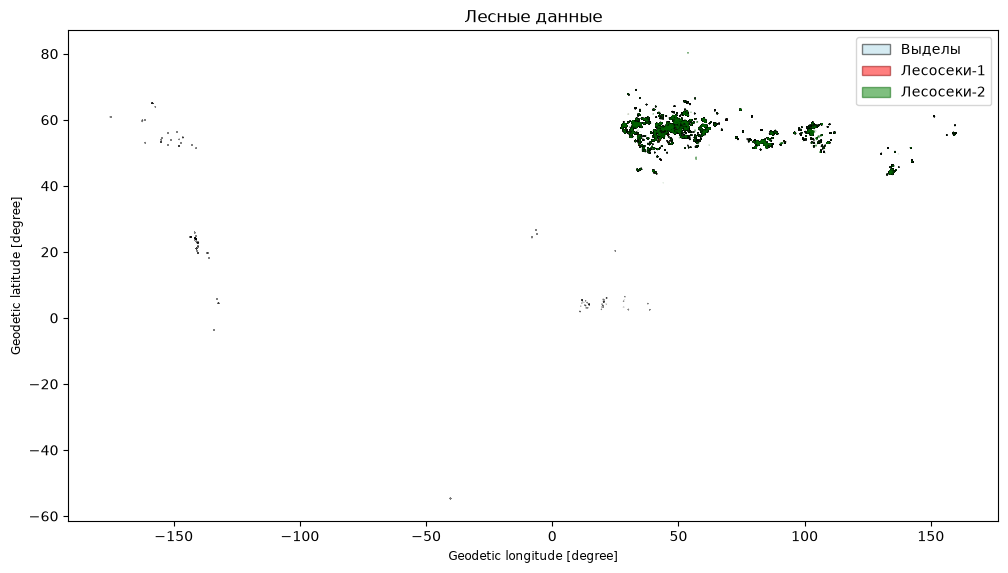

In [37]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(12, 12))

df_geo_area.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5, label='Выделы')
df_geo_forestsec1.plot(ax=ax, color='red', edgecolor='darkred', alpha=0.5, label='Лесосеки-1')
df_geo_forestsec2.plot(ax=ax, color='green', edgecolor='darkgreen', alpha=0.5, label='Лесосеки-2')

plt.legend()
plt.title("Лесные данные")
plt.show()